In [27]:
# imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import re
from scipy.stats import f_oneway


# machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

## Data cleaning and preparing

In [28]:
tsc = pd.read_csv("Tsc2-LE_data_exported_20251015.csv")
tsc.head()

,date,rat_name,rat_ID,DOB,Sex,weight,Genotype,HL_date,invalid,file_name,...,stim_type,analysis_type,complete_block_count,trial_count,hit_percent,FA_percent,UUID,block_size,line,genotype
0,20230117,GP5,161,20220206,Male,483.0,Tsc2_LE_Het,NaN,NaN,32kHz_5-65dB_50ms_4s,...,tone,Tone (Single),30.0,300,0.757143,0.044444,20230117112140_40.0530014187098_3.23855481992454,10,Tsc2,Het
1,20230117,GP6,162,20220206,Male,570.0,Tsc2_LE_WT,NaN,NaN,8kHz_30-90dB_50ms_4s,...,tone,Tone (Single),43.0,433,0.917492,0.223077,20230117112140_180.444997921586_2.7957715020537,10,Tsc2,WT
2,20230117,GP1,144,20220127,Male,558.0,Tsc2_LE_Het,NaN,NaN,4kHz_30-60dB_50ms_4s,...,tone,Tone (Single),45.0,453,0.852201,0.207407,20230117122835_82.660998031497_2.42393043181062,10,Tsc2,Het
3,20230117,GP2,150,20220127,Male,509.0,Tsc2_LE_WT,NaN,NaN,4kHz_30-90dB_50ms_4s,...,tone,Tone (Single),41.0,410,0.853659,0.227642,20230117122835_117.839000746608_2.72426594934181,10,Tsc2,WT
4,20230117,GP3,145,20220127,Male,636.0,Tsc2_LE_Het,NaN,NaN,8kHz_30-90dB_50ms_4s,...,tone,Tone (Single),45.0,459,0.825545,0.108696,20230117133538_98.7920008599758_1.44631039885978,10,Tsc2,Het


In [29]:
tsc["date"].unique

<bound method Series.unique of 0       20230117
1       20230117
2       20230117
3       20230117
4       20230117
          ...   
8323    20251015
8324    20251015
8325    20251015
8326    20251015
8327    20251015
Name: date, Length: 8328, dtype: int64>

In [30]:
tsc.columns

Index(['date', 'rat_name', 'rat_ID', 'DOB', 'Sex', 'weight', 'Genotype',
       'HL_date', 'invalid', 'file_name', 'experiment', 'phase', 'task',
       'detail', 'stim_type', 'analysis_type', 'complete_block_count',
       'trial_count', 'hit_percent', 'FA_percent', 'UUID', 'block_size',
       'line', 'genotype'],
      dtype='object')

In [31]:
tsc_trials = pd.read_csv("Tsc2-LE_data_exported_trials_20251015.csv")
tsc_trials.head()

,Time_since_file_start_(s),Stim_ID,Trial_type,Attempts_to_complete,Response,Reaction_(s),Type,Stim Source,Freq (kHz),Inten (dB),Dur (ms),Nose Out TL (s),Time Out (s),Delay (s),Trial_number,Block_number,complete_block_number,UUID
0,40.053001,1,1,5,Hit,0.081321,1,tone,32.0,5,50,2,0,3.238555,1,1,1.0,20230117112140_40.0530014187098_3.23855481992454
1,67.011998,8,0,3,CR,2.000002,0,tone,32.0,-100,50,2,4,2.403731,2,1,1.0,20230117112140_40.0530014187098_3.23855481992454
2,74.789999,7,1,2,Hit,0.196028,1,tone,32.0,65,50,2,0,3.582482,3,1,1.0,20230117112140_40.0530014187098_3.23855481992454
3,100.449003,8,0,3,CR,2.000000,0,tone,32.0,-100,50,2,4,2.399536,4,1,1.0,20230117112140_40.0530014187098_3.23855481992454
4,105.440999,4,1,1,Hit,0.242583,1,tone,32.0,35,50,2,0,2.494313,5,1,1.0,20230117112140_40.0530014187098_3.23855481992454


In [32]:
tsc.shape

(8328, 24)

In [33]:
tsc.isna().sum()

date                       0
rat_name                   0
rat_ID                     0
DOB                        0
Sex                        0
weight                     2
Genotype                   0
HL_date                 8328
invalid                 8328
file_name                  0
experiment                 0
phase                      0
task                       0
detail                  1192
stim_type                  0
analysis_type              0
complete_block_count       0
trial_count                0
hit_percent                0
FA_percent               377
UUID                       0
block_size                 0
line                       0
genotype                   0
dtype: int64

In [34]:
tsc_trials.isna().sum()

Time_since_file_start_(s)        0
Stim_ID                          0
Trial_type                       0
Attempts_to_complete             0
Response                         0
Reaction_(s)                     0
Type                             0
Stim Source                      0
Freq (kHz)                       0
Inten (dB)                       0
Dur (ms)                         0
Nose Out TL (s)                  0
Time Out (s)                     0
Delay (s)                        0
Trial_number                     0
Block_number                     0
complete_block_number        40329
UUID                             0
dtype: int64

In [51]:
tsc_trials.columns

Index(['Time_since_file_start_(s)', 'Stim_ID', 'Trial_type',
       'Attempts_to_complete', 'Response', 'Reaction_(s)', 'Type',
       'Stim Source', 'Freq (kHz)', 'Inten (dB)', 'Dur (ms)',
       'Nose Out TL (s)', 'Time Out (s)', 'Delay (s)', 'Trial_number',
       'Block_number', 'complete_block_number', 'UUID'],
      dtype='object')

In [46]:
# Check that UUID exists in both
print("UUID in tsc:", 'UUID' in tsc.columns)
print("UUID in tsc_trials:", 'UUID' in tsc_trials.columns)

UUID in tsc: True
UUID in tsc_trials: True


In [45]:
# Check for duplicates
print("Unique UUIDs in tsc:", tsc['UUID'].nunique())
print("Unique UUIDs in tsc_trials:", tsc_trials['UUID'].nunique())

# Optional: check if UUIDs match perfectly between datasets
common = set(tsc['UUID']).intersection(set(tsc_trials['UUID']))
print(f"Common UUIDs: {len(common)}")

Unique UUIDs in tsc: 8326
Unique UUIDs in tsc_trials: 8328
Common UUIDs: 8326


In [37]:
tsc["date"].value_counts()

date
20221208    22
20220926    20
20230117    18
20220920    18
20220827    18
            ..
20240819     2
20251013     2
20250905     2
20220514     1
20250318     1
Name: count, Length: 860, dtype: int64

In [38]:
tsc["rat_name"].value_counts()

rat_name
RP1        443
RP2        435
TP5        384
GP2        382
TP6        370
GP1        369
TP4        349
TP2        347
TP1        320
Orange6    291
Orange4    291
Orange5    291
Orange2    288
Orange1    286
RP4        244
RP6        238
RP5        230
RP3        218
Orange3    216
Yellow1    216
Yellow2    215
GP4        181
TP3        179
GP5        178
GP6        178
GP3        164
Blue4      116
Lime4      115
Blue6      115
Blue3      114
Blue5      112
Lime3       80
Lime1       52
Lime2       46
Green1      36
Green2      35
Pink1       34
Pink2       34
Pink3       34
Pink4       34
Green3      34
Green4      34
Name: count, dtype: int64

In [39]:
tsc["rat_ID"].value_counts()

rat_ID
137    443
138    435
163    384
150    382
164    370
144    369
160    349
157    347
156    320
311    291
319    291
306    291
316    288
315    286
140    244
142    238
141    230
139    218
318    216
324    216
327    215
153    181
159    179
161    178
162    178
145    164
381    116
332    115
385    115
370    114
384    112
331     80
328     52
330     46
905     36
906     35
898     34
900     34
901     34
903     34
947     34
948     34
Name: count, dtype: int64

In [47]:
tsc_trials["UUID"].value_counts()

UUID
20240221115324_377.004995942116_3.46455342707717      710
20251009133920_93.5820009559393_0.702689238832728     664
20221213112840_132.857999950647_3.47186139057743      648
20251010133641_154.144003987312_1.45668960412565      640
20251015131856_10.9419945627451_1.57773720924952      630
                                                     ... 
20220808113123_896.487000212073_0.0645656003352914      2
20220802144909_948.515997827053_0.136584376631916       2
20220606155510_370.0179990381_0.216239739659829         2
20220606155504_2762.88300231099_0.274213096502729       1
20220801143930_6.42500035464764_0.341956279456211       1
Name: count, Length: 8328, dtype: int64

In [48]:
tsc['date'] = pd.to_datetime(tsc['date'], format='%Y%m%d', errors='coerce')
tsc = tsc.dropna(subset=['weight'])

In [50]:
tsc["file_name"].value_counts()

file_name
BBN_20-80dB_50ms_4s               330
16kHz_70dB_8kHz_70dB_300ms_12s    282
BBN_20-80dB_50ms_8s               244
BBN_30-90dB_50ms_4s               225
BBN_20-80dB_300ms_4s              195
                                 ... 
BBN_60dB_4catch_0s                  1
4kHz_60dB_3catch_4s                 1
4kHz_60dB_3catch_2s                 1
BBN_25-55dB_50ms_4s                 1
16-9kHz_70dB_300ms_12s_NG3          1
Name: count, Length: 447, dtype: int64

In [43]:
#def load_data(trials_path, info_path):
    #df_trials = pd.read_csv(trials_path)
    #df_info = pd.read_csv(info_path)
    #return df_trials, df_info

#def uuid_comparer(df1, df2):
    #shared_UUIDs = set(df1['UUID']).intersection(set(df2['UUID']))
    #print(f" Shared UUIDs: {len(shared_UUIDs)}")
    #print(f" UUIDs only in df1: {len(set(df1['UUID']) - shared_UUIDs)}")
    #print(f" UUIDs only in df2: {len(set(df2['UUID']) - shared_UUIDs)}")
    #return shared_UUIDs

#def data_cleaner(df_trials, df_info, shared_UUIDs):
    #"""
    #Filters for shared UUIDs and merges trials with info data.
    #Keeps only relevant/valid rows for analysis.
    #"""
    # Convert shared_UUIDs to list for filtering
    #shared_UUIDs = list(shared_UUIDs)

    # Merge both datasets on UUID
    #merged_df = pd.merge(df_trials, df_info, on="UUID", how="inner")

    # Keep only UUIDs present in both
    #merged_df = merged_df[merged_df['UUID'].isin(shared_UUIDs)]

    # Drop duplicates (if any)
    #merged_df = merged_df.drop_duplicates()
    # Make sure info_df has one row per UUID
    #info_unique = df_info.drop_duplicates(subset=['UUID'])

    # Merge with trials (many-to-one)
    #merged_df = pd.merge(df_trials, info_unique, on="UUID", how="inner")

    #print(f"Merged dataset shape: {merged_df.shape}")

    # Optional: Keep only complete blocks (if that column exists)
    #if 'complete_block_number' in merged_df.columns:
        #merged_df = merged_df[merged_df['complete_block_number'] > 1]

    #print(f" Merged dataset shape: {merged_df.shape}")
    #return merged_df

In [52]:
df_trials = pd.read_csv("Tsc2-LE_data_exported_trials_20251015.csv")
df_info = pd.read_csv("Tsc2-LE_data_exported_20251015.csv")

print("Trials shape:", df_trials.shape)
print("Info shape:", df_info.shape)

# Parse file_name in df_info
def parse_file_name(name):
    """
    Parse file_name strings like 'BBN_20-80dB_50ms_4s' into components.
    """
    name = str(name)
    parts = name.split('_')
    
    result = {
        'StimType': parts[0] if len(parts) > 0 else None,
        'IntensityRange': parts[1] if len(parts) > 1 else None,
        'Duration_ms': None,
        'Delay_s': None
    }

    # Extract duration (e.g., '50ms')
    dur = re.search(r'(\d+)ms', name)
    if dur:
        result['Duration_ms'] = int(dur.group(1))

    # Extract delay (e.g., '4s')
    delay = re.search(r'(\d+)s', name)
    if delay:
        result['Delay_s'] = int(delay.group(1))

    return pd.Series(result)

# Apply parsing
parsed_info = df_info['file_name'].apply(parse_file_name)
df_info = pd.concat([df_info, parsed_info], axis=1)

# Drop any duplicate UUIDs from df_info (just in case)
df_info_unique = df_info.drop_duplicates(subset=['UUID'])
print("Unique UUIDs in info:", df_info_unique['UUID'].nunique())

# Merge (many-to-one join on UUID)
merged_df = pd.merge(df_trials, df_info_unique, on="UUID", how="left")

# Sanity checks 
print("\n Merge Summary:")
print(f"Trials rows: {len(df_trials)}")
print(f"Info unique UUIDs: {len(df_info_unique)}")
print(f"Merged rows: {len(merged_df)}")
print(f"Unique UUIDs in merged_df: {merged_df['UUID'].nunique()}")

# Quick column check
print("\nColumns in merged dataset:")
print(merged_df.columns.tolist())

# Preview final merged data
print("\nPreview of merged dataset:")
display(merged_df.head())


Trials shape: (2952182, 18)
Info shape: (8328, 24)
Unique UUIDs in info: 8328

 Merge Summary:
Trials rows: 2952182
Info unique UUIDs: 8328
Merged rows: 2952182
Unique UUIDs in merged_df: 8328

Columns in merged dataset:
['Time_since_file_start_(s)', 'Stim_ID', 'Trial_type', 'Attempts_to_complete', 'Response', 'Reaction_(s)', 'Type', 'Stim Source', 'Freq (kHz)', 'Inten (dB)', 'Dur (ms)', 'Nose Out TL (s)', 'Time Out (s)', 'Delay (s)', 'Trial_number', 'Block_number', 'complete_block_number', 'UUID', 'date', 'rat_name', 'rat_ID', 'DOB', 'Sex', 'weight', 'Genotype', 'HL_date', 'invalid', 'file_name', 'experiment', 'phase', 'task', 'detail', 'stim_type', 'analysis_type', 'complete_block_count', 'trial_count', 'hit_percent', 'FA_percent', 'block_size', 'line', 'genotype', 'StimType', 'IntensityRange', 'Duration_ms', 'Delay_s']

Preview of merged dataset:


,Time_since_file_start_(s),Stim_ID,Trial_type,Attempts_to_complete,Response,Reaction_(s),Type,Stim Source,Freq (kHz),Inten (dB),...,trial_count,hit_percent,FA_percent,block_size,line,genotype,StimType,IntensityRange,Duration_ms,Delay_s
0,40.053001,1,1,5,Hit,0.081321,1,tone,32.0,5,...,300,0.757143,0.044444,10,Tsc2,Het,32kHz,5-65dB,50.0,4
1,67.011998,8,0,3,CR,2.000002,0,tone,32.0,-100,...,300,0.757143,0.044444,10,Tsc2,Het,32kHz,5-65dB,50.0,4
2,74.789999,7,1,2,Hit,0.196028,1,tone,32.0,65,...,300,0.757143,0.044444,10,Tsc2,Het,32kHz,5-65dB,50.0,4
3,100.449003,8,0,3,CR,2.000000,0,tone,32.0,-100,...,300,0.757143,0.044444,10,Tsc2,Het,32kHz,5-65dB,50.0,4
4,105.440999,4,1,1,Hit,0.242583,1,tone,32.0,35,...,300,0.757143,0.044444,10,Tsc2,Het,32kHz,5-65dB,50.0,4


In [53]:
merged_df.columns

Index(['Time_since_file_start_(s)', 'Stim_ID', 'Trial_type',
       'Attempts_to_complete', 'Response', 'Reaction_(s)', 'Type',
       'Stim Source', 'Freq (kHz)', 'Inten (dB)', 'Dur (ms)',
       'Nose Out TL (s)', 'Time Out (s)', 'Delay (s)', 'Trial_number',
       'Block_number', 'complete_block_number', 'UUID', 'date', 'rat_name',
       'rat_ID', 'DOB', 'Sex', 'weight', 'Genotype', 'HL_date', 'invalid',
       'file_name', 'experiment', 'phase', 'task', 'detail', 'stim_type',
       'analysis_type', 'complete_block_count', 'trial_count', 'hit_percent',
       'FA_percent', 'block_size', 'line', 'genotype', 'StimType',
       'IntensityRange', 'Duration_ms', 'Delay_s'],
      dtype='object')

**Proportion of one-attempt trials per rat**

In [64]:
# Calculate proportion of one-attempt trials per rat
prop_one_attempt = (
    merged_df.groupby('rat_ID')['Attempts_to_complete']
    .apply(lambda x: (x == 1).sum() / len(x))
    .reset_index(name='prop_one_attempt_trials')
)

# Merge it back into merged_df
merged_df = merged_df.merge(prop_one_attempt, on='rat_ID', how='left')

# Check results
print(merged_df[['rat_ID', 'Attempts_to_complete', 'prop_one_attempt_trials']].head())

   rat_ID  Attempts_to_complete  prop_one_attempt_trials
0     161                     5                 0.805106
1     161                     3                 0.805106
2     161                     2                 0.805106
3     161                     3                 0.805106
4     161                     1                 0.805106


In [65]:
merged_df["rat_ID"].value_counts()

rat_ID
138    185786
144    163395
137    146408
150    145694
316    131851
319    123326
160    115430
157    114950
141    114037
315    113138
140    109372
156    106943
164    100357
163     98708
142     96793
139     92449
311     91657
318     91538
306     76445
162     75946
153     71286
145     69311
161     54681
159     50821
370     44484
327     43770
332     36530
381     34224
385     33582
324     33517
384     32072
331     23416
328     18530
330     15941
905     15469
947     14456
948     12454
901     12221
906     11900
903     10745
900      9919
898      8630
Name: count, dtype: int64

## Gender Difference & TSC Genotypes

**Gender & Genotypes & First-attempt completion rate (Use the mean value for each rats)**

**Tsc2_LE_WT & Tsc2_LE_Het**

In [66]:
# Aggregate by rat_ID
rat_summary = merged_df.groupby(['rat_ID', 'Sex', 'Genotype'])['prop_one_attempt_trials'].mean().reset_index()
print(rat_summary.head(15))

    rat_ID     Sex     Genotype  prop_one_attempt_trials
0      137    Male   Tsc2_LE_WT                 0.745014
1      138    Male  Tsc2_LE_Het                 0.751892
2      139    Male  Tsc2_LE_Het                 0.657433
3      140    Male   Tsc2_LE_WT                 0.779761
4      141    Male  Tsc2_LE_Het                 0.781317
5      142    Male   Tsc2_LE_WT                 0.628496
6      144    Male  Tsc2_LE_Het                 0.665008
7      145    Male  Tsc2_LE_Het                 0.718544
8      150    Male   Tsc2_LE_WT                 0.710043
9      153    Male   Tsc2_LE_WT                 0.725009
10     156  Female  Tsc2_LE_Het                 0.636872
11     157  Female   Tsc2_LE_WT                 0.732588
12     159  Female  Tsc2_LE_Het                 0.718640
13     160  Female   Tsc2_LE_WT                 0.765858
14     161    Male  Tsc2_LE_Het                 0.805106


**Visualize proportion of one-attempt trials per rat by gender and genotype**

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10804\565794696.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


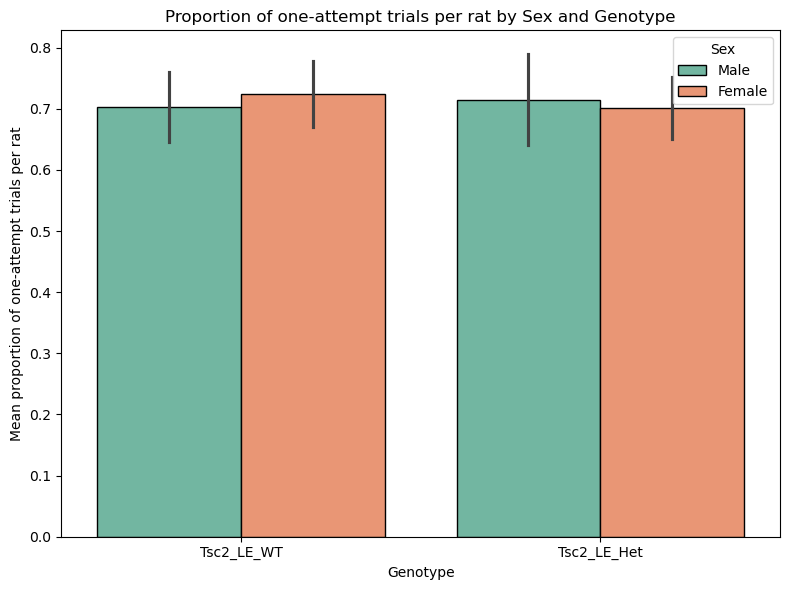

In [67]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=rat_summary,
    x='Genotype', y='prop_one_attempt_trials', hue='Sex',
    ci='sd', palette='Set2', edgecolor='black'
)
plt.title('Proportion of one-attempt trials per rat by Sex and Genotype')
plt.ylabel('Mean proportion of one-attempt trials per rat')
plt.xlabel('Genotype')
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

**Check for Normality**

Shapiro-Wilk p-value: 0.1546


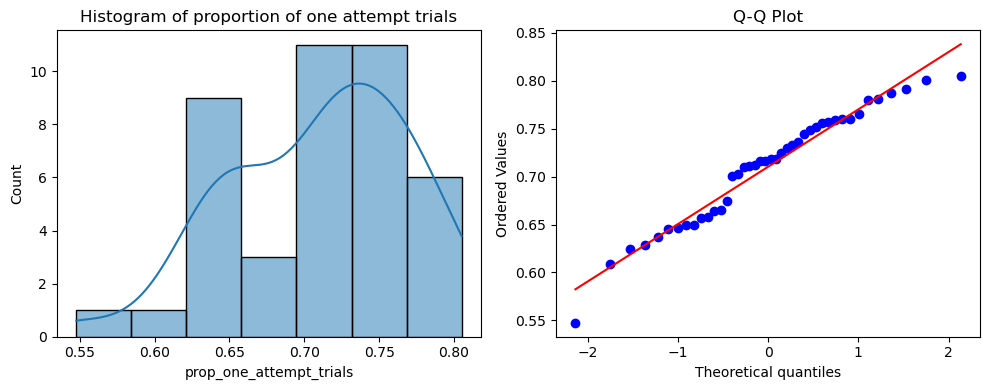

In [68]:
from scipy.stats import shapiro, normaltest, zscore
import scipy.stats as stats

# Shapiro-Wilk test
stat, p = shapiro(rat_summary['prop_one_attempt_trials'])
print(f"Shapiro-Wilk p-value: {p:.4f}")

# Histogram and Q-Q plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(rat_summary['prop_one_attempt_trials'], kde=True)
plt.title('Histogram of proportion of one attempt trials')

plt.subplot(1, 2, 2)
stats.probplot(rat_summary['prop_one_attempt_trials'], dist="norm", plot=plt)
plt.title('Q-Q Plot')

plt.tight_layout()
plt.show()

In [72]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

rat_summary['prop_one_attempt_trials_z'] = zscore(rat_summary['prop_one_attempt_trials'])

model = ols('prop_one_attempt_trials_z ~ C(Sex) * C(Genotype)', data=rat_summary).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                       sum_sq    df         F    PR(>F)
C(Sex)               0.050413   1.0  0.046674  0.830111
C(Genotype)          0.024845   1.0  0.023002  0.880253
C(Sex):C(Genotype)   0.880402   1.0  0.815100  0.372304
Residual            41.044340  38.0       NaN       NaN


A two-way ANOVA was conducted to examine the effects of sex and genotype on the proportion of one-attempt trials in the Tsc2 rat groups. The analysis revealed no significant main effects of sex, F(1,38) = 0.047, p = .83, or genotype, F(1,38) = 0.023, p = .88. The interaction between sex and genotype was also not significant, F(1,38) = 0.82, p = .37. These results suggest that neither sex nor genotype meaningfully influenced the proportion of trials completed in a single attempt. In other words, both male and female rats across genotypes exhibited similar behavioral patterns in their trial attempts.

**Furthur Visualizations**

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10804\1319239856.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10804\1319239856.py:2: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  sns.barplot(


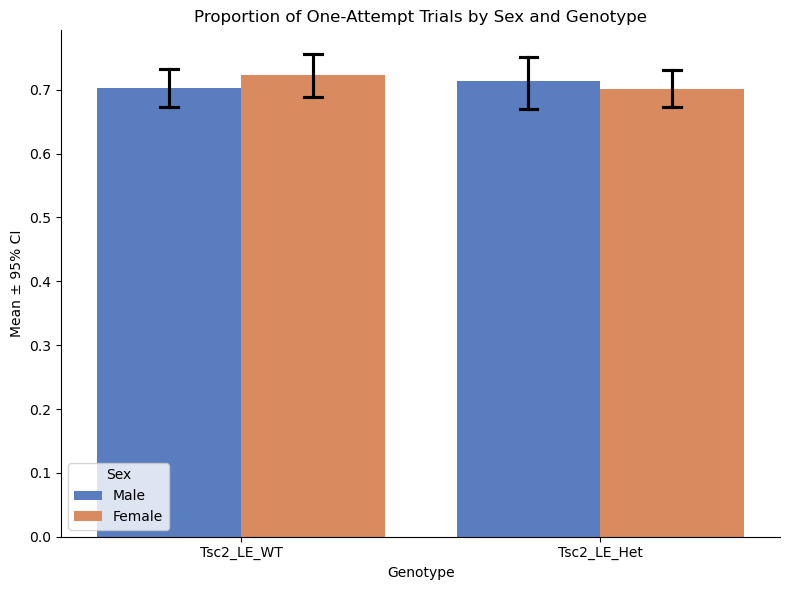

In [74]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=rat_summary,
    x='Genotype', y='prop_one_attempt_trials', hue='Sex',
    ci=95, capsize=.1, palette='muted', errcolor='black'
)
plt.title('Proportion of One-Attempt Trials by Sex and Genotype')
plt.ylabel('Mean ± 95% CI')
plt.xlabel('Genotype')
plt.legend(title='Sex')
sns.despine()
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10804\2248809170.py:6: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


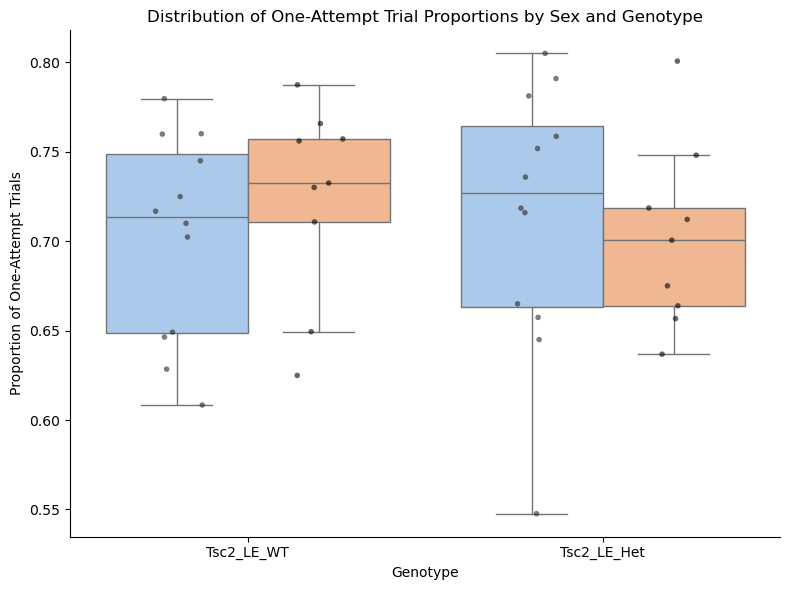

In [75]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=rat_summary, x='Genotype', y='prop_one_attempt_trials',
    hue='Sex', palette='pastel', fliersize=0
)
sns.stripplot(
    data=rat_summary, x='Genotype', y='prop_one_attempt_trials',
    hue='Sex', dodge=True, jitter=0.15, alpha=0.6, color='black', size=4
)
plt.title('Distribution of One-Attempt Trial Proportions by Sex and Genotype')
plt.ylabel('Proportion of One-Attempt Trials')
plt.xlabel('Genotype')
plt.legend([],[], frameon=False)  # removes duplicate legend
sns.despine()
plt.tight_layout()
plt.show()

<Figure size 600x500 with 0 Axes>

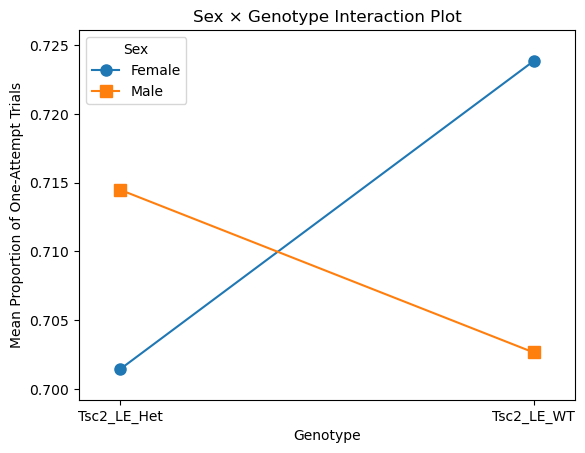

In [76]:
from statsmodels.graphics.factorplots import interaction_plot

plt.figure(figsize=(6,5))
interaction_plot(
    rat_summary['Genotype'], rat_summary['Sex'], rat_summary['prop_one_attempt_trials'],
    colors=['#1f77b4', '#ff7f0e'], markers=['o', 's'], ms=8
)
plt.ylabel('Mean Proportion of One-Attempt Trials')
plt.title('Sex × Genotype Interaction Plot')
plt.show()

**Hypothesis: Autism model rats will have a lower # of single-attempt trials for longer delay times (>2.5 seconds) than wild type rats**


In [78]:
long_delay_df = merged_df[merged_df['Delay (s)'] > 2.5]
print(f"Trials with Delay > 2.5s: {len(long_delay_df)}")

# Compute per-rat proportion of single-attempt trials for long delays
rat_long_delay = (
    long_delay_df.groupby(['rat_ID', 'Genotype', 'Sex'])['Attempts_to_complete']
    .apply(lambda x: (x == 1).mean())
    .reset_index(name='prop_one_attempt_longDelay')
)

print(rat_long_delay.head())

Trials with Delay > 2.5s: 1402345
   rat_ID     Genotype   Sex  prop_one_attempt_longDelay
0     137   Tsc2_LE_WT  Male                    0.683358
1     138  Tsc2_LE_Het  Male                    0.689629
2     139  Tsc2_LE_Het  Male                    0.602055
3     140   Tsc2_LE_WT  Male                    0.722062
4     141  Tsc2_LE_Het  Male                    0.743104


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10804\3867438624.py:6: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


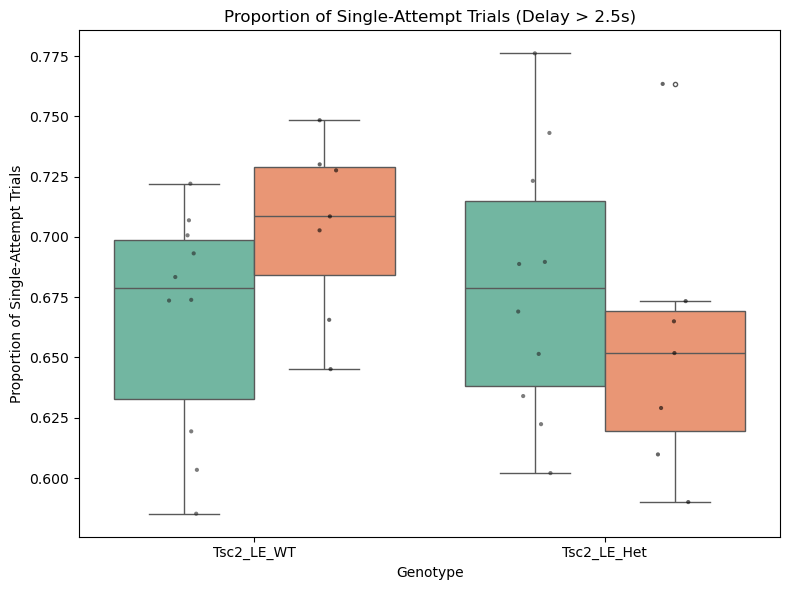

In [79]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=rat_long_delay, x='Genotype', y='prop_one_attempt_longDelay', hue='Sex',
    palette='Set2', fliersize=3
)
sns.stripplot(
    data=rat_long_delay, x='Genotype', y='prop_one_attempt_longDelay', hue='Sex',
    dodge=True, alpha=0.6, color='black', size=3
)
plt.title('Proportion of Single-Attempt Trials (Delay > 2.5s)')
plt.ylabel('Proportion of Single-Attempt Trials')
plt.xlabel('Genotype')
plt.legend([], [], frameon=False)  # remove duplicate legend
plt.tight_layout()
plt.show()

**Check for Normality**

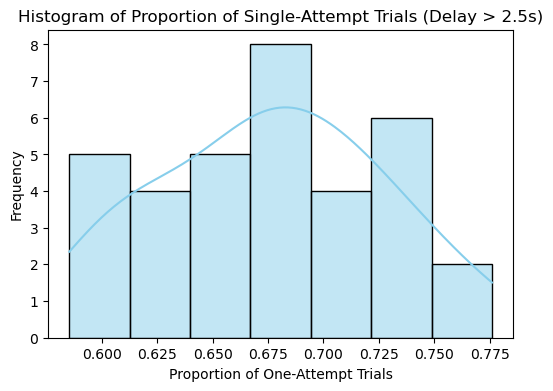

In [83]:
plt.figure(figsize=(6,4))
sns.histplot(rat_long_delay['prop_one_attempt_longDelay'], kde=True, color='skyblue')
plt.title("Histogram of Proportion of Single-Attempt Trials (Delay > 2.5s)")
plt.xlabel("Proportion of One-Attempt Trials")
plt.ylabel("Frequency")
plt.show()

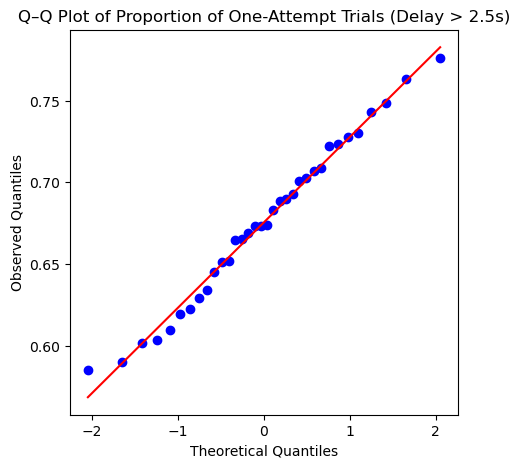

In [84]:
plt.figure(figsize=(5,5))
stats.probplot(rat_long_delay['prop_one_attempt_longDelay'], dist="norm", plot=plt)
plt.title("Q–Q Plot of Proportion of One-Attempt Trials (Delay > 2.5s)")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Observed Quantiles")
plt.show()

In [80]:
from scipy.stats import shapiro

stat, p = shapiro(rat_long_delay['prop_one_attempt_longDelay'])
print(f"Shapiro-Wilk p-value: {p:.4f}")

Shapiro-Wilk p-value: 0.7868


Since p > 0.05, and the graph shows it is approximately normal, so I proceed with Independent Samples t-test (since we're comparing 2 groups)

In [85]:
from scipy.stats import ttest_ind

het = rat_long_delay[rat_long_delay['Genotype'].str.contains('Het', case=False)]['prop_one_attempt_longDelay']
wt = rat_long_delay[rat_long_delay['Genotype'].str.contains('WT', case=False)]['prop_one_attempt_longDelay']

t_stat, p_val = ttest_ind(het, wt, equal_var=False)  # Welch’s t-test
print(f"T-test result: t = {t_stat:.3f}, p = {p_val:.4f}")

T-test result: t = -0.697, p = 0.4912


I tested whether autism-model (Tsc2_LE_Het) rats exhibited a lower proportion of single-attempt trials under longer delay conditions (>2.5 s) compared to wild-type (Tsc2_LE_WT) rats. For each rat, I calculated the proportion of trials completed in one attempt across all long-delay trials. An independent samples t-test revealed that the difference between genotypes was not statistically significant (p = .4912), indicating that the data do not show evidence that the autism model rats differ in single-attempt performance at long delays. These results suggest that prolonged waiting intervals may not differentially affect trial persistence between autism-model and control rats.

**Try testing hypothesis about genotype × sex effects on the proportion of single-attempt trials under long delays (>2.5s)**

In [86]:
# Subset trials with long delays
long_delay_df = merged_df[merged_df['Delay (s)'] > 2.5]

# Compute per-rat proportion of single-attempt trials (Delay > 2.5s)
rat_long_delay = (
    long_delay_df.groupby(['rat_ID', 'Genotype', 'Sex'])['Attempts_to_complete']
    .apply(lambda x: (x == 1).mean())
    .reset_index(name='prop_one_attempt_longDelay')
)

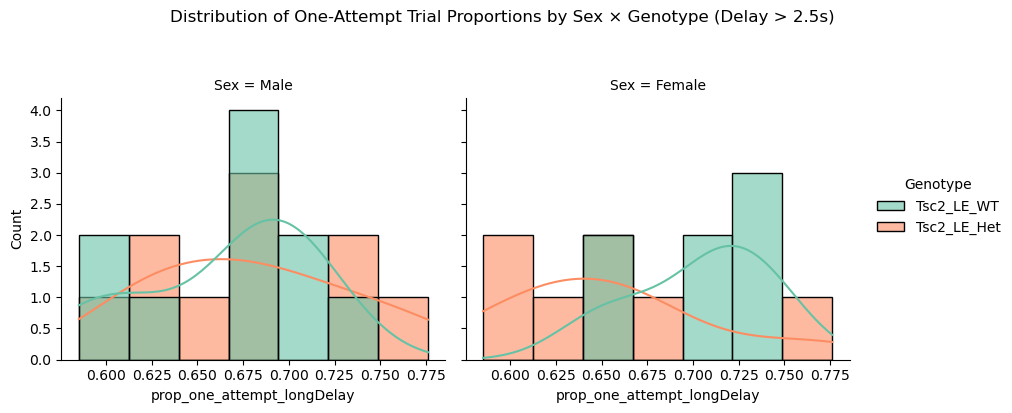

In [89]:
sns.displot(
    data=rat_long_delay,
    x='prop_one_attempt_longDelay',
    hue='Genotype',
    col='Sex',
    kind='hist',
    kde=True,
    palette='Set2',
    alpha=0.6,
    height=4,
    aspect=1.1
)
plt.subplots_adjust(top=0.8)
plt.suptitle("Distribution of One-Attempt Trial Proportions by Sex × Genotype (Delay > 2.5s)", y=1.02)
plt.show()

**Check for Normality**

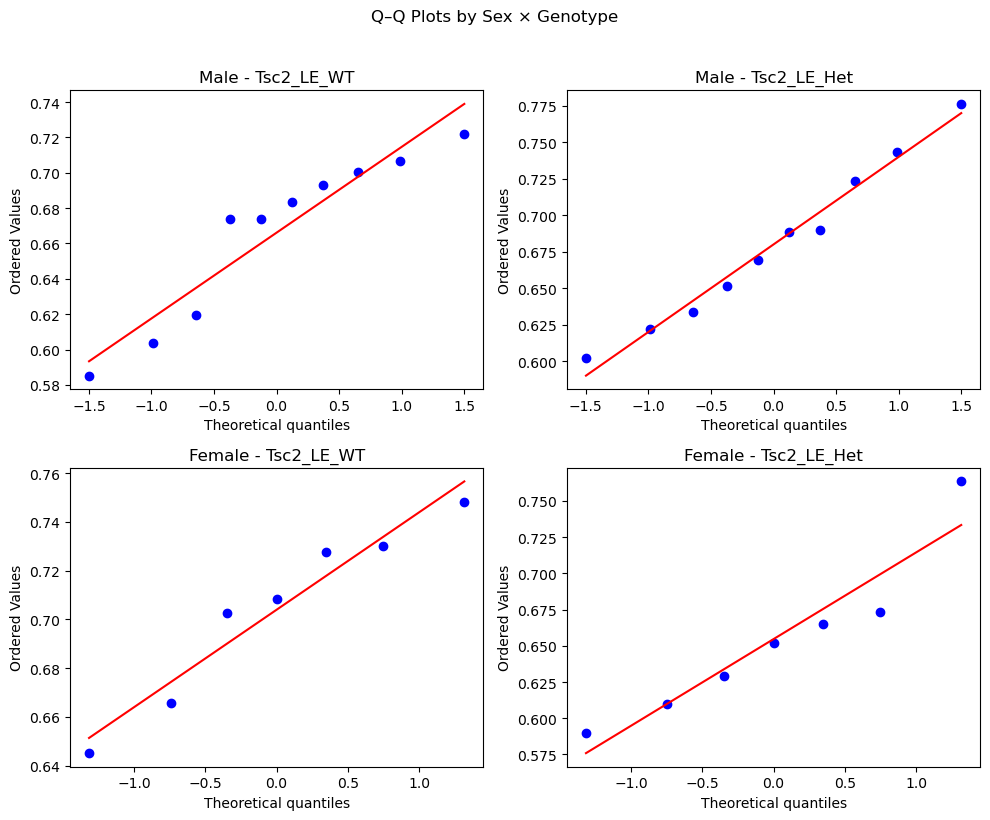

In [90]:
sexes = rat_long_delay['Sex'].unique()
genotypes = rat_long_delay['Genotype'].unique()

plt.figure(figsize=(10,8))
plot_i = 1
for sex in sexes:
    for geno in genotypes:
        subset = rat_long_delay[(rat_long_delay['Sex']==sex) & (rat_long_delay['Genotype']==geno)]
        plt.subplot(len(sexes), len(genotypes), plot_i)
        stats.probplot(subset['prop_one_attempt_longDelay'], dist="norm", plot=plt)
        plt.title(f"{sex} - {geno}")
        plot_i += 1
plt.suptitle("Q–Q Plots by Sex × Genotype", y=1.02)
plt.tight_layout()
plt.show()

**Two-Way ANOVA**

In [91]:
model = ols('prop_one_attempt_longDelay ~ C(Sex) * C(Genotype)', data=rat_long_delay).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                      sum_sq    df         F    PR(>F)
C(Sex)              0.000322   1.0  0.129202  0.721779
C(Genotype)         0.001264   1.0  0.506960  0.481959
C(Sex):C(Genotype)  0.008215   1.0  3.294877  0.079506
Residual            0.074800  30.0       NaN       NaN


A two-way ANOVA was conducted to examine the effects of sex and genotype on the proportion of single-attempt trials for long delay conditions (>2.5 s). The results indicated no significant main effects of sex, F(1,30) = 0.13, p = .72, or genotype, F(1,30) = 0.51, p = .48. However, the interaction between sex and genotype approached significance, F(1,30) = 3.29, p = .08, suggesting a potential trend in which the impact of genotype on trial persistence may vary across sexes. While this trend did not meet the conventional significance threshold, it points to a possible sex-dependent effect that may warrant further investigation with larger sample sizes.

## Weight Difference

**Define “significant weight drop” (>7%)**

In [92]:
# Sort by rat_ID and date
merged_df['date'] = pd.to_datetime(merged_df['date'], format='%Y%m%d')
merged_df = merged_df.sort_values(['rat_ID', 'date'])

# Compute daily % weight change per rat
merged_df['pct_weight_change'] = merged_df.groupby('rat_ID')['weight'].pct_change() * 100

# Flag significant drops (>7%)
merged_df['sig_drop_7'] = merged_df['pct_weight_change'] < -7

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10804\2049270573.py:6: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  merged_df['pct_weight_change'] = merged_df.groupby('rat_ID')['weight'].pct_change() * 100


In [93]:
# Mark current and next-day behavior after a weight drop
merged_df['drop_next_day'] = merged_df.groupby('rat_ID')['sig_drop_7'].shift(1)

def classify_day(row):
    if row['sig_drop_7']:
        return 'Drop Day'
    elif row['drop_next_day']:
        return 'Post-Drop Day'
    else:
        return 'Stable Day'

merged_df['drop_status'] = merged_df.apply(classify_day, axis=1)

“Drop Day” → day of >7% drop

“Post-Drop Day” → day after a drop

“Stable Day” → no recent significant drop

In [95]:
rat_behavior_summary = (
    merged_df.groupby(['rat_ID', 'drop_status'])['Attempts_to_complete']
    .mean()
    .reset_index(name='mean_attempts')
)
print(rat_behavior_summary.head(15))

    rat_ID    drop_status  mean_attempts
0      137  Post-Drop Day       1.000000
1      137     Stable Day       1.503139
2      138  Post-Drop Day       3.000000
3      138     Stable Day       1.477369
4      139  Post-Drop Day       1.000000
5      139     Stable Day       1.696035
6      140  Post-Drop Day       2.000000
7      140     Stable Day       1.402803
8      141  Post-Drop Day       1.000000
9      141     Stable Day       1.373601
10     142  Post-Drop Day       1.000000
11     142     Stable Day       1.682877
12     144  Post-Drop Day       1.000000
13     144     Stable Day       1.560345
14     145  Post-Drop Day       1.000000


**Visualizations**

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10804\3972522286.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rat_behavior_summary, x='drop_status', y='mean_attempts',


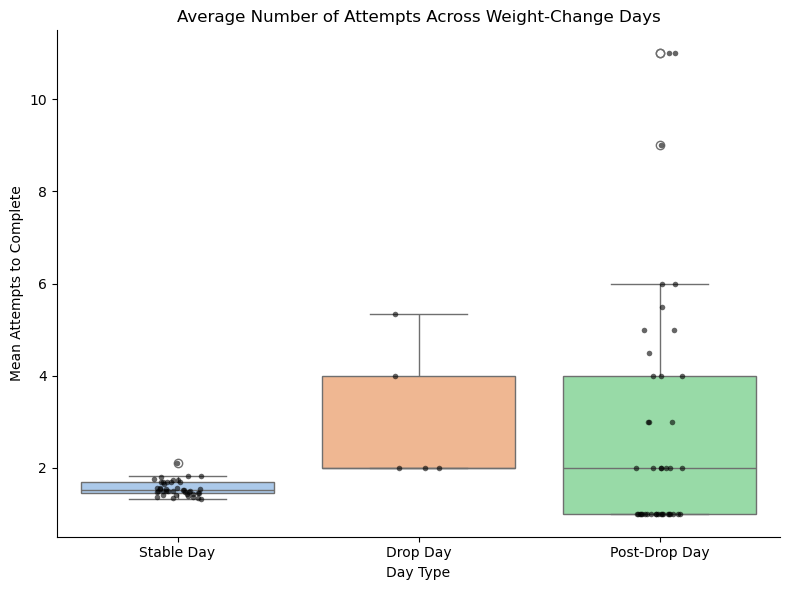

In [96]:
plt.figure(figsize=(8,6))
sns.boxplot(data=rat_behavior_summary, x='drop_status', y='mean_attempts',
            palette='pastel', order=['Stable Day', 'Drop Day', 'Post-Drop Day'])
sns.stripplot(data=rat_behavior_summary, x='drop_status', y='mean_attempts',
              color='black', alpha=0.6, size=4)
plt.title('Average Number of Attempts Across Weight-Change Days')
plt.xlabel('Day Type')
plt.ylabel('Mean Attempts to Complete')
sns.despine()
plt.tight_layout()
plt.show()

**Line plot: within-rat change over time**

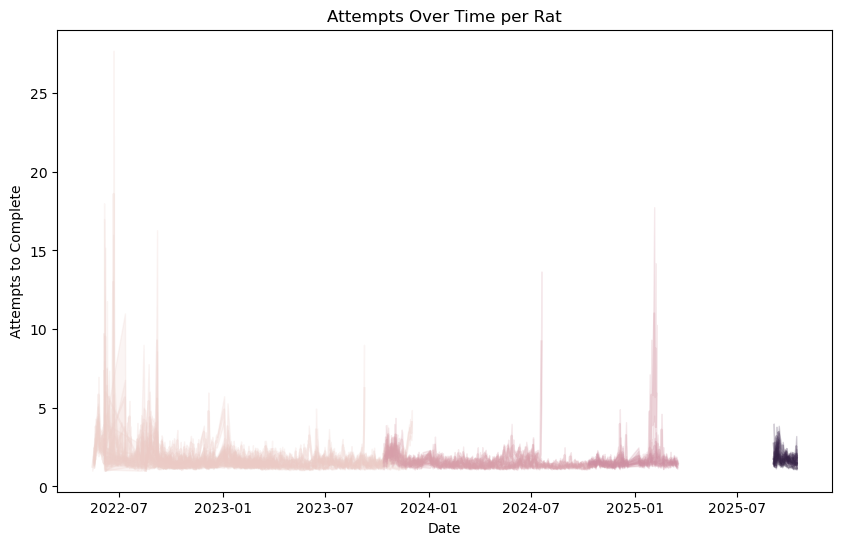

In [97]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=merged_df,
    x='date', y='Attempts_to_complete', hue='rat_ID', alpha=0.3, legend=False
)
plt.title('Attempts Over Time per Rat')
plt.xlabel('Date')
plt.ylabel('Attempts to Complete')
plt.show()

**Overlay Weight**

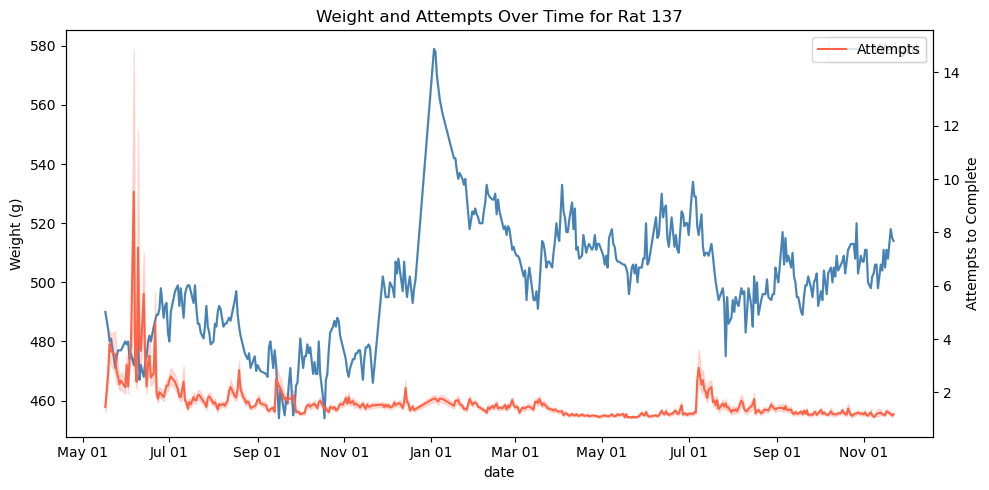

In [98]:
import matplotlib.dates as mdates

sample_rat = merged_df[merged_df['rat_ID'] == merged_df['rat_ID'].unique()[0]]

fig, ax1 = plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()

sns.lineplot(data=sample_rat, x='date', y='weight', color='steelblue', ax=ax1, label='Weight')
sns.lineplot(data=sample_rat, x='date', y='Attempts_to_complete', color='tomato', ax=ax2, label='Attempts')

ax1.set_ylabel('Weight (g)')
ax2.set_ylabel('Attempts to Complete')
ax1.set_title(f"Weight and Attempts Over Time for Rat {sample_rat['rat_ID'].iloc[0]}")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.tight_layout()
plt.show()

**Hypothesis test: Does drop status affect behavior?**

In [99]:
anova_model = ols('mean_attempts ~ C(drop_status)', data=rat_behavior_summary).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
print(anova_table)

                    sum_sq    df         F    PR(>F)
C(drop_status)   36.730694   2.0  5.309228  0.006697
Residual        297.485795  86.0       NaN       NaN


To examine whether significant short-term weight loss influenced behavioral patience, trials were categorized as “Stable,” “Drop,” or “Post-Drop” days based on whether a rat experienced more than a 7% decrease in body weight compared to the previous day. A one-way ANOVA compared the mean number of attempts across these conditions. The analysis revealed a significant main effect of drop status, p < .05 (p = 0.006697), indicating that rats showed higher mean attempts (lower patience) following a significant weight drop”. Visualization of mean attempts across drop conditions supports this result, suggesting that physiological stress or energy loss may transiently reduce behavioral persistence in the Tsc2 cohort.